<a href="https://colab.research.google.com/github/CaoTrongNghia/dipoleMoment-dftEstimator/blob/main/drive_mounted_dft_spice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This model is training to act as a Machine Learning Interatomic Potential
—essentially a neural network surrogate that replaces expensive DFT calculations.

Specifically, given a 3D arrangement of atoms in space, it estimates:
1. The Potential Energy Surface (PES): How much quantum-mechanical potential energy the molecule holds in that exact 3D shape.
2. The Atomic Forces: The precise push/pull vector forces acting on every individual atom ($\mathbf{F} = -\nabla E$).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
checkpoint_dir = "/content/drive/MyDrive/torchmdnet_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "latest_checkpoint.pt")

Mounted at /content/drive


In [ ]:
!pip install rdkit
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torch_geometric

# Clone TorchMD-NET fresh
!git clone https://github.com/torchmd/torchmd-net.git
%cd torchmd-net

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 32.8 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.1 MB/s eta 0:00:00
Cloning into 'torchmd-net'...
remote: Enumerating objects: 8799, done.
remote: Counting objects: 100% (448/448), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 8799 (delta 406), reused 382 (delta 376), pack-reused 8351 (from 4)
Receiving objects: 100% (8799/8799), 189.03 MiB | 17.88 MiB/s, done.
Resolving deltas: 100% (6133/6133), done.
/content/torchmd-net


In [ ]:
# Install TorchMD-NET
!pip install -e . --no-cache-dir --default-timeout=200

# torchvision and torchaudio are not needed
!pip install h5py ase
!pip install wandb

Obtaining file:///content/torchmd-net
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 151.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 158.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.3/164.3 MB 225.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 256.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 315.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.1/553.1 MB 211.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1

In [ ]:
import sys
sys.path.append("/usr/local/lib/python3.11/site-packages/")
sys.path.append("/content/torchmd-net")

In [ ]:
import urllib.request
import os

# Download SPICE 1.1.4 from Zenodo
url = "https://zenodo.org/records/8222043/files/SPICE-1.1.4.hdf5"
filename = "SPICE.hdf5"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("Download complete!")
else:
    print("SPICE dataset already exists.")

In [ ]:
import h5py
import torch
from torch_geometric.data import Data
import numpy as np
import os
import random
import json
import gc  # Garbage collector to force clear RAM

# summary of what is going on:
# the spice dataset is shuffled via molecules (each one having many orientations)
# then from that "list", it's cut up into parts to be loaded separately in epochs (preventing memory overload)

def process_and_shard_spice_safe(file_path, save_dir="/content/spice_shards", chunk_size=10000):
    os.makedirs(save_dir, exist_ok=True)

    # 1. Gather all unique molecule names and shuffle THEM (not individual frames)
    print("Step 1: Gathering and shuffling unique molecule names...")
    with h5py.File(file_path, 'r') as f:
        mol_names = list(f.keys())

    random.seed(42)
    random.shuffle(mol_names)
    print(f"Found {len(mol_names)} unique molecules. Global order randomized.")

    # 2. Extract sequentially per molecule (Fast, zero HDF5 thrashing)
    print("\nStep 2: Processing structures and saving shards...")
    current_chunk = []
    shard_idx = 0
    total_saved = 0

    with h5py.File(file_path, 'r') as f:
        for mol_idx, mol_name in enumerate(mol_names):
            mol_group = f[mol_name]

            # Pull arrays into RAM once per molecule (extremely light & fast)
            atomic_numbers_np = mol_group['atomic_numbers'][:]
            conformations_np = mol_group['conformations'][:]
            gradients_np = mol_group['dft_total_gradient'][:]
            energies_np = mol_group['formation_energy'][:]

            num_conformations = conformations_np.shape[0]
            atomic_numbers = torch.tensor(atomic_numbers_np, dtype=torch.long)

            for i in range(num_conformations):
                pos = torch.tensor(conformations_np[i], dtype=torch.float32)
                neg_dy = torch.tensor(gradients_np[i], dtype=torch.float32)
                y = torch.tensor([energies_np[i]], dtype=torch.float32)

                if torch.isnan(pos).any() or torch.isnan(y).any():
                    continue

                molecule_graph = Data(z=atomic_numbers, pos=pos, y=y, neg_dy=neg_dy)
                current_chunk.append(molecule_graph)

                # Save when chunk is full
                if len(current_chunk) == chunk_size:
                    torch.save(current_chunk, f"{save_dir}/shard_{shard_idx}.pt")
                    total_saved += len(current_chunk)
                    print(f"Saved {save_dir}/shard_{shard_idx}.pt | Total samples processed: {total_saved}")

                    current_chunk = []  # Empty the list
                    shard_idx += 1
                    gc.collect()     # Force python to clear out old shard data instantly

            # Print a heartbeat progress tracker every 500 molecules
            if mol_idx % 500 == 0 and mol_idx > 0:
                print(f"   -> Progress: Unpacked {mol_idx}/{len(mol_names)} molecules...")

        # Save any leftover graphs
        if current_chunk:
            torch.save(current_chunk, f"{save_dir}/shard_{shard_idx}.pt")
            total_saved += len(current_chunk)
            shard_idx += 1
            print(f"Saved final shard_{shard_idx-1}.pt. Total valid dataset size: {total_saved}")

    # 3. Save the critical metadata file
    metadata = {
        "total_samples": total_saved,
        "num_shards": shard_idx,
        "chunk_size": chunk_size
    }
    with open(f"{save_dir}/metadata.json", "w") as mfile:
        json.dump(metadata, mfile)

    print("\nSuccess! metadata.json written to disk. Ready for training loop cells.")

# --- Run the script ---
raw_hdf5_path = "/content/SPICE.hdf5"
process_and_shard_spice_safe(raw_hdf5_path, chunk_size=10000)

Step 1: Gathering and shuffling unique molecule names...
Found 19238 unique molecules. Global order randomized.

Step 2: Processing structures and saving shards...
Saved /content/spice_shards/shard_0.pt | Total samples processed: 10000
Saved /content/spice_shards/shard_1.pt | Total samples processed: 20000
   -> Progress: Unpacked 500/19238 molecules...
Saved /content/spice_shards/shard_2.pt | Total samples processed: 30000
Saved /content/spice_shards/shard_3.pt | Total samples processed: 40000
Saved /content/spice_shards/shard_4.pt | Total samples processed: 50000
   -> Progress: Unpacked 1000/19238 molecules...
Saved /content/spice_shards/shard_5.pt | Total samples processed: 60000
Saved /content/spice_shards/shard_6.pt | Total samples processed: 70000
Saved /content/spice_shards/shard_7.pt | Total samples processed: 80000
   -> Progress: Unpacked 1500/19238 molecules...
Saved /content/spice_shards/shard_8.pt | Total samples processed: 90000
Saved /content/spice_shards/shard_9.pt | T

In [ ]:
# =====================================================================
# NEW CELL 1: BACKUP TO GOOGLE DRIVE (RUN THIS ONCE, THE FIRST TIME ONLY)
# =====================================================================
from google.colab import drive
import os

# Mount your Drive
drive.mount('/content/drive')

# Create a permanent home for your project shards on Drive
drive_project_dir = "/content/drive/MyDrive/dft_project"
os.makedirs(drive_project_dir, exist_ok=True)

print("Compressing shards into a single zip file to prevent Drive network bottlenecks...")
# Zipping creates one file, preserving your nested shards perfectly
!zip -r -q /content/spice_shards.zip /content/spice_shards

print("Copying zip file to Google Drive...")
!cp /content/spice_shards.zip {drive_project_dir}/spice_shards.zip
print("All shards safely archived to Google Drive! You will never have to run Cells 1 & 2 again.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Compressing shards into a single zip file to prevent Drive network bottlenecks...
Copying zip file to Google Drive...
All shards safely archived to Google Drive! You will never have to run Cells 1 & 2 again.


In [ ]:
# =====================================================================
# NEW CELL 2: RESTORE FROM DRIVE (RUN THIS ON ALL FUTURE RUNS)
# =====================================================================
from google.colab import drive
import os

# Mount your Drive
drive.mount('/content/drive')

drive_project_dir = "/content/drive/MyDrive/dft_project"
zip_path_drive = os.path.join(drive_project_dir, "spice_shards.zip")

if os.path.exists(zip_path_drive):
    print("Found persistent dataset archive on Drive. Copying to local environment...")
    !cp {zip_path_drive} /content/

    print("Unzipping to ultra-fast local disk storage...")
    !unzip -q /content/spice_shards.zip -d /
    print("Dataset successfully restored to /content/spice_shards. Proceed directly to DataLoaders.")
else:
    print(" Error: Could not find 'spice_shards.zip' on your Drive. Ensure you ran the First-Time Save cell.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found persistent dataset archive on Drive. Copying to local environment...
Unzipping to ultra-fast local disk storage...
Dataset successfully restored to /content/spice_shards. Proceed directly to DataLoaders.


In [ ]:
import os
import re
import json
import torch
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader

class ShardLoaderDataset(Dataset):
    def __init__(self, shard_files, chunk_size):
        self.shard_files = shard_files
        self.chunk_size = chunk_size

        if not self.shard_files:
            self.total_graphs = 0
        elif len(self.shard_files) == 1:
            self.total_graphs = len(torch.load(self.shard_files[0], weights_only=False))
        else:
            # Since files are now perfectly sorted numerically,
            # only the literal last shard file in the entire dataset can be incomplete.
            last_shard_len = len(torch.load(self.shard_files[-1], weights_only=False))
            self.total_graphs = (len(self.shard_files) - 1) * chunk_size + last_shard_len

        self.current_shard_idx = -1
        self.current_shard_data = None

    def __len__(self):
        return self.total_graphs

    def __getitem__(self, idx):
        shard_idx = idx // self.chunk_size
        internal_idx = idx % self.chunk_size

        if shard_idx != self.current_shard_idx:
            self.current_shard_data = torch.load(self.shard_files[shard_idx], weights_only=False)
            self.current_shard_idx = shard_idx

        return self.current_shard_data[internal_idx]

# --- 1. LOAD METADATA ---
shard_dir = "/content/spice_shards"

with open(f"{shard_dir}/metadata.json", "r") as mfile:
    metadata = json.load(mfile)

CHUNK_SIZE = metadata["chunk_size"]
print(f"Loaded metadata. Detected chunk size: {CHUNK_SIZE}")

# --- 2. NATURAL SORTING ---
# This lambda extracts the number from 'shard_XX.pt' so 2 comes before 10.
all_shards = [os.path.join(shard_dir, f) for f in os.listdir(shard_dir) if f.endswith('.pt')]
all_shards.sort(key=lambda f: int(re.findall(r'\d+', os.path.basename(f))[0]))

# --- 3. TRAIN/VAL SPLIT ---
# Now that it's sorted numerically, the incomplete shard is guaranteed to be at the very end of val_shards
split_idx = int(0.8 * len(all_shards))
train_shards = all_shards[:split_idx]
val_shards = all_shards[split_idx:]

# --- 4. INITIALIZE DATASETS ---
train_dataset = ShardLoaderDataset(train_shards, chunk_size=CHUNK_SIZE)
val_dataset = ShardLoaderDataset(val_shards, chunk_size=CHUNK_SIZE)

# shuffle=False is critical here to prevent disk-thrashing!
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Setup Complete!")
print(f"Train graphs: {len(train_dataset)} (across {len(train_shards)} shards)")
print(f"Val graphs: {len(val_dataset)} (across {len(val_shards)} shards)")

/usr/local/lib/python3.13/dist-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Loaded metadata. Detected chunk size: 10000
Setup Complete!
Train graphs: 890000 (across 89 shards)
Val graphs: 220165 (across 23 shards)


In [ ]:
import os
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torchmdnet.models.model import create_model
import warnings
from google.colab import drive

# 1. Mount Google Drive and set up your checkpoint pathway
drive.mount('/content/drive')
checkpoint_dir = "/content/drive/MyDrive/torchmdnet_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "latest_checkpoint.pt")

# 2. Custom Dictionary that absorbs KeyErrors
class Config(dict):
    def __getitem__(self, key):
        if key not in self:
            if key == 'atom_filter': return -1
            if key == 'layernorm_on_vec': return 'whitened'
            if key == 'aggr': return 'add'
            return None
        return super().__getitem__(key)

# 3. Define the network parameters
model_config = Config({
    'model': 'equivariant-transformer',
    'embedding_dimension': 128,
    'num_layers': 6,
    'num_rbf': 32,
    'rbf_type': 'gauss',
    'trainable_rbf': False,
    'activation': 'silu',
    'attn_activation': 'silu',
    'num_heads': 8,
    'distance_influence': 'both',
    'cutoff_lower': 0.0,
    'cutoff_upper': 5.0,
    'max_num_neighbors': 32,
    'neighbor_embedding': True,
    'derivative': True,          # Crucial for calculating forces
    'max_z': 100,
    'output_model': 'Scalar',
    'precision': 32,
    'reduce_op': 'add',
    'prior_model': None,
    'atom_filter': -1,
    'layernorm_on_vec': 'whitened',
    'aggr': 'add'
})

# 4. Compile the base model architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = create_model(model_config).to(device)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-8)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# 5. Check Google Drive to resume or start fresh
start_epoch = 1
best_val_loss = float('inf')

if os.path.exists(checkpoint_path):
    print("Found an existing checkpoint! Resuming from previous session...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1

    if 'best_val_loss' in checkpoint:
        best_val_loss = checkpoint['best_val_loss']

    print(f"Weights loaded successfully. Resuming at Epoch {start_epoch}!")
    print(f"Current best validation loss to beat: {best_val_loss:.4f}")
else:
    print("No checkpoint found. Starting training from scratch (Epoch 1).")

warnings.filterwarnings("ignore", message=".*skipping gradients.*")

# 7. Training Function with Crash Guard
def train_one_epoch():
    model.train()
    total_loss = 0.0
    successful_graphs = 0

    for batch_idx, batch in enumerate(train_loader):
        try:
            batch = batch.to(device)
            optimizer.zero_grad(set_to_none=True)

            batch.pos.requires_grad_(True)
            pred_energy, pred_forces = model(batch.z, batch.pos, batch.batch)

            # Fix: Use .view(-1) instead of .squeeze() to safeguard against batches of size 1
            loss_energy = F.mse_loss(pred_energy.view(-1), batch.y.view(-1))
            loss_forces = F.mse_loss(pred_forces, batch.neg_dy)
            combined_loss = loss_energy + (10.0 * loss_forces)

            combined_loss.backward()
            optimizer.step()

            total_loss += combined_loss.item() * batch.num_graphs
            successful_graphs += batch.num_graphs

            if batch_idx % 200 == 0:
                print(f"    Batch {batch_idx}/{len(train_loader)} completed...")

        except Exception as e:
            # Crash Guard: Logs the error and moves on to save the rest of your training run
            print(f"\n Alert: Skipped anomalies in Train Batch {batch_idx}. Error: {e}")
            continue

    return total_loss / successful_graphs if successful_graphs > 0 else 0.0

# 8. Validation Function (Gradients active ONLY for pos vectors)
def validate():
    model.eval()
    total_val_loss = 0.0
    successful_graphs = 0

    # Do NOT use torch.no_grad() because torchmdnet needs gradients to evaluate forces!
    for batch_idx, batch in enumerate(val_loader):
        try:
            batch = batch.to(device)
            batch.pos.requires_grad_(True)

            pred_energy, pred_forces = model(batch.z, batch.pos, batch=batch.batch)

            loss_energy = F.mse_loss(pred_energy.view(-1), batch.y.view(-1))
            loss_forces = F.mse_loss(pred_forces, batch.neg_dy)
            combined_loss = loss_energy + (10.0 * loss_forces)

            total_val_loss += combined_loss.item() * batch.num_graphs
            successful_graphs += batch.num_graphs
        except Exception as e:
            print(f"\nAlert: Skipped anomalies in Val Batch {batch_idx}. Error: {e}")
            continue

    return total_val_loss / successful_graphs if successful_graphs > 0 else 0.0

#  --- MAIN EXECUTION LOOP ---
total_target_epochs = 50

for epoch in range(start_epoch, total_target_epochs + 1):
    print(f"\nStarting Epoch {epoch:02d}/{total_target_epochs}...")

    train_loss = train_one_epoch()
    val_loss = validate()

    print(f"Epoch {epoch:02d} Complete. Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    scheduler.step(val_loss)

    is_best = False
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        is_best = True

    checkpoint_data = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'best_val_loss': best_val_loss
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"Google Drive backup updated for Epoch {epoch:02d}.")

    if is_best:
        best_model_path = os.path.join(checkpoint_dir, "best_model.pt")
        torch.save(checkpoint_data, best_model_path)
        print(f"New best model! Val loss dropped to {val_loss:.4f}. Saved to best_model.pt")

/content/torchmd-net/torchmdnet/models/utils.py:461: SyntaxWarning: invalid escape sequence '\c'
  \text{Swish}(x) = x \cdot \sigma(\beta x)
/content/torchmd-net/torchmdnet/models/utils.py:481: SyntaxWarning: invalid escape sequence '\o'
  \text{SwiGLU}(x) = \text{Linear}_1(x) \otimes \text{Swish}(\text{Linear}_2(x))


Warp 1.17.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.17.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found an existing checkpoint! Resuming from previous session...
Weights loaded successfully. Resuming at Epoch 49!
Current best validation loss to beat: 0.0017

Starting Epoch 49/50...
Module neighbors_brute_specialized_fwd_P0_T1_L1_float32 71c3630 load on device 'cuda:0' took 911.78 ms  (compiled)
    Batch 0/55625 completed...
    Batch 200/55625 completed...
    Batch 400/55625 completed...
    Batch 600/55625 completed...
    Batch 800/55625 completed...
    Batch 1000/55625 completed...
    Batch 1200/55625 completed...
    Batch 1400/55625 completed...
    Batch 1600/55625 completed...
    Batch 1800/55625 completed...
    Batch 2000/55625 completed.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Validation DataLoader ready with 220165 graphs across 23 shards.
Loading checkpoint weights from: /content/drive/MyDrive/torchmdnet_checkpoints/best_model.pt
Loaded Epoch 48 model successfully!
Running validation inference...

Energy MAE : 0.019878
Force MAE  : 0.003908


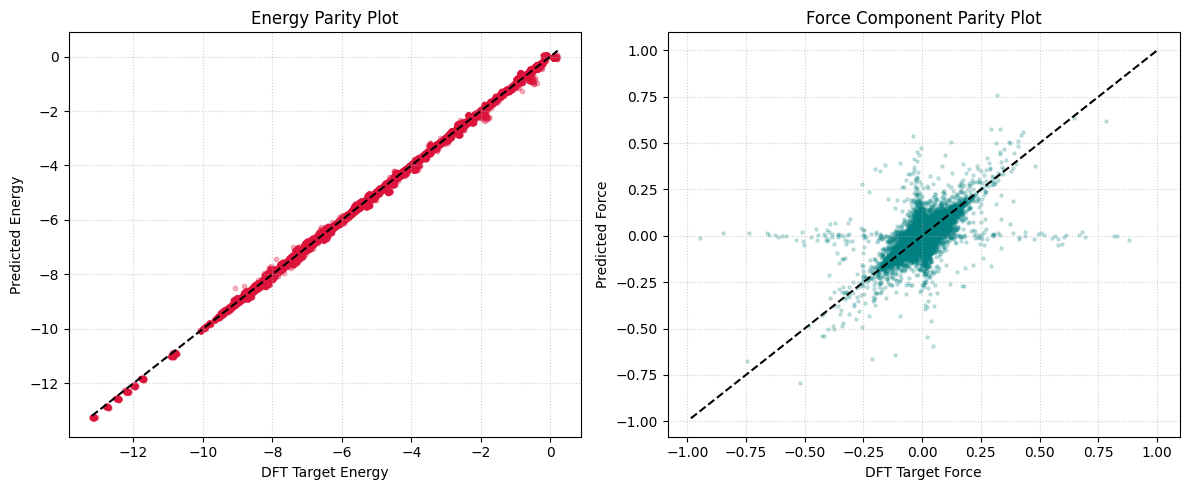

In [ ]:
import os
import re
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader
from torchmdnet.models.model import create_model
from google.colab import drive
import warnings
warnings.filterwarnings("ignore", message=".*skipping gradients.*")

# 1. Mount Drive & Setup Paths
drive.mount('/content/drive')
drive_project_dir = "/content/drive/MyDrive/dft_project"
checkpoint_dir = "/content/drive/MyDrive/torchmdnet_checkpoints"
best_model_path = os.path.join(checkpoint_dir, "best_model.pt")
zip_path_drive = os.path.join(drive_project_dir, "spice_shards.zip")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Extract Shards if not already present on local disk
if not os.path.exists("/content/spice_shards"):
    print("Unzipping dataset shards from Drive to fast local storage...")
    !unzip -q {zip_path_drive} -d /
    print("Unzip complete!")

# 3. Define Dataset Class & Rebuild val_loader
class ShardLoaderDataset(Dataset):
    def __init__(self, shard_files, chunk_size):
        self.shard_files = shard_files
        self.chunk_size = chunk_size

        if not self.shard_files:
            self.total_graphs = 0
        elif len(self.shard_files) == 1:
            self.total_graphs = len(torch.load(self.shard_files[0], weights_only=False))
        else:
            last_shard_len = len(torch.load(self.shard_files[-1], weights_only=False))
            self.total_graphs = (len(self.shard_files) - 1) * chunk_size + last_shard_len

        self.current_shard_idx = -1
        self.current_shard_data = None

    def __len__(self):
        return self.total_graphs

    def __getitem__(self, idx):
        shard_idx = idx // self.chunk_size
        internal_idx = idx % self.chunk_size

        if shard_idx != self.current_shard_idx:
            self.current_shard_data = torch.load(self.shard_files[shard_idx], weights_only=False)
            self.current_shard_idx = shard_idx

        return self.current_shard_data[internal_idx]

shard_dir = "/content/spice_shards"
with open(f"{shard_dir}/metadata.json", "r") as mfile:
    metadata = json.load(mfile)

CHUNK_SIZE = metadata["chunk_size"]
all_shards = [os.path.join(shard_dir, f) for f in os.listdir(shard_dir) if f.endswith('.pt')]
all_shards.sort(key=lambda f: int(re.findall(r'\d+', os.path.basename(f))[0]))

# Restrict to the 20% validation split
split_idx = int(0.8 * len(all_shards))
val_shards = all_shards[split_idx:]

val_dataset = ShardLoaderDataset(val_shards, chunk_size=CHUNK_SIZE)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print(f"Validation DataLoader ready with {len(val_dataset)} graphs across {len(val_shards)} shards.")

# 4. Model Configuration & Loading
class Config(dict):
    def __getitem__(self, key):
        if key not in self:
            if key == 'atom_filter': return -1
            if key == 'layernorm_on_vec': return 'whitened'
            if key == 'aggr': return 'add'
            return None
        return super().__getitem__(key)

model_config = Config({
    'model': 'equivariant-transformer',
    'embedding_dimension': 128,
    'num_layers': 6,
    'num_rbf': 32,
    'rbf_type': 'gauss',
    'trainable_rbf': False,
    'activation': 'silu',
    'attn_activation': 'silu',
    'num_heads': 8,
    'distance_influence': 'both',
    'cutoff_lower': 0.0,
    'cutoff_upper': 5.0,
    'max_num_neighbors': 32,
    'neighbor_embedding': True,
    'derivative': True,
    'max_z': 100,
    'output_model': 'Scalar',
    'precision': 32,
    'reduce_op': 'add',
    'prior_model': None,
    'atom_filter': -1,
    'layernorm_on_vec': 'whitened',
    'aggr': 'add'
})

model = create_model(model_config).to(device)

if os.path.exists(best_model_path):
    print(f"Loading checkpoint weights from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded Epoch {checkpoint['epoch']} model successfully!")
else:
    raise FileNotFoundError(f"Could not find model file at {best_model_path}")

model.eval()

# 5. Run Validation
all_pred_e, all_true_e = [], []
all_pred_f, all_true_f = [], []

print("Running validation inference...")
for batch_idx, batch in enumerate(val_loader):
    try:
        batch = batch.to(device)
        batch.pos.requires_grad_(True)

        with torch.enable_grad():
            pred_e, pred_f = model(batch.z, batch.pos, batch=batch.batch)

        all_pred_e.extend(pred_e.view(-1).detach().cpu().numpy())
        all_true_e.extend(batch.y.view(-1).cpu().numpy())
        all_pred_f.append(pred_f.detach().cpu().numpy())
        all_true_f.append(batch.neg_dy.cpu().numpy())
    except Exception as e:
        print(f"Skipped batch {batch_idx}: {e}")
        continue

# 6. Calculate Metrics and Render Parity Plots
pred_e_arr, true_e_arr = np.array(all_pred_e), np.array(all_true_e)
pred_f_arr = np.concatenate(all_pred_f, axis=0)
true_f_arr = np.concatenate(all_true_f, axis=0)

e_mae = np.mean(np.abs(pred_e_arr - true_e_arr))
f_mae = np.mean(np.abs(pred_f_arr - true_f_arr))

print("\n" + "=" * 40)
print(f"Energy MAE : {e_mae:.6f}")
print(f"Force MAE  : {f_mae:.6f}")
print("=" * 40)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(true_e_arr, pred_e_arr, alpha=0.3, s=10, color='crimson')
axes[0].plot([true_e_arr.min(), true_e_arr.max()], [true_e_arr.min(), true_e_arr.max()], 'k--', label='1:1 Line')
axes[0].set_title("Energy Parity Plot")
axes[0].set_xlabel("DFT Target Energy")
axes[0].set_ylabel("Predicted Energy")
axes[0].grid(True, linestyle=':', alpha=0.6)

f_true_flat, f_pred_flat = true_f_arr.flatten(), pred_f_arr.flatten()
axes[1].scatter(f_true_flat[::10], f_pred_flat[::10], alpha=0.2, s=5, color='teal')
axes[1].plot([f_true_flat.min(), f_true_flat.max()], [f_true_flat.min(), f_true_flat.max()], 'k--', label='1:1 Line')
axes[1].set_title("Force Component Parity Plot")
axes[1].set_xlabel("DFT Target Force")
axes[1].set_ylabel("Predicted Force")
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Meaning of the result:
Left plot: how the predicted and actual energy match up (so high accuracy PES)
Right plot: how the predicted and target forces match up (good avg force accuracy, but underpredicts strong forces in atomic collisions)